In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas import get_dummies
from scipy.constants import precision
from sklearn.cluster import k_means
from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier
from webencodings import encode


In [11]:
df=pd.read_csv("students-data-50.1.csv")

In [6]:
df.head(10)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,M,21,92,3.5,78,9,2024-06-10,Bengaluru,Yes
1,Priya,Female,22,88%,4.0,85,10,10/06/2024,Bangalore,No
2,Amit,MALE,20,76,2.5,67,8,2024/06/12,Mysuru,Y
3,Sneha,F,23,95,5.0,91,10,12-06-2024,Mysore,N
4,Kiran,Male,21,NaN,3.0,72,7,2024-06-15,Hubballi,Yes
5,Anjali,female,20,89,4.5,88,9,15/06/2024,Hubli,No
6,Vikram,M,24,72,2.0,61,6,2024-06-18,Dharwad,Y
7,Neha,Female,22,91,NaN,93,10,18/06/2024,Dharwad,Yes
8,Rohan,Male,19,68,1.5,55,5,2024/06/20,Belagavi,No
9,Divya,FEMALE,21,84,3.0,76,8,20-06-2024,Belgaum,N


In [7]:
df.head(50)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,M,21,92,3.5,78,9,2024-06-10,Bengaluru,Yes
1,Priya,Female,22,88%,4.0,85,10,10/06/2024,Bangalore,No
2,Amit,MALE,20,76,2.5,67,8,2024/06/12,Mysuru,Y
3,Sneha,F,23,95,5.0,91,10,12-06-2024,Mysore,N
4,Kiran,Male,21,NaN,3.0,72,7,2024-06-15,Hubballi,Yes
5,Anjali,female,20,89,4.5,88,9,15/06/2024,Hubli,No
6,Vikram,M,24,72,2.0,61,6,2024-06-18,Dharwad,Y
7,Neha,Female,22,91,NaN,93,10,18/06/2024,Dharwad,Yes
8,Rohan,Male,19,68,1.5,55,5,2024/06/20,Belagavi,No
9,Divya,FEMALE,21,84,3.0,76,8,20-06-2024,Belgaum,N


In [8]:
df.describe()

,Study_Hours,Previous_Marks
count,49.000000,50.000000
mean,3.122449,75.520000
std,1.256361,14.195774
min,0.500000,45.000000
25%,2.500000,65.250000
50%,3.000000,75.500000
75%,4.000000,88.000000
max,5.500000,96.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   50 non-null     str    
 1   Gender                 50 non-null     str    
 2   Age                    49 non-null     str    
 3   Attendance (%)         48 non-null     str    
 4   Study_Hours            49 non-null     float64
 5   Previous_Marks         50 non-null     int64  
 6   Assignments_Completed  49 non-null     str    
 7   Join_Date              50 non-null     str    
 8   City                   50 non-null     str    
 9   Extra_Classes          50 non-null     str    
dtypes: float64(1), int64(1), str(8)
memory usage: 4.0 KB


In [12]:
df.isnull().sum()

Name                     0
Gender                   0
Age                      1
Attendance (%)           2
Study_Hours              1
Previous_Marks           0
Assignments_Completed    1
Join_Date                0
City                     0
Extra_Classes            0
dtype: int64

In [13]:
df.columns

Index(['Name', 'Gender', 'Age', 'Attendance (%)', 'Study_Hours',
       'Previous_Marks', 'Assignments_Completed', 'Join_Date', 'City',
       'Extra_Classes'],
      dtype='str')

In [14]:
df.duplicated().sum()

np.int64(2)

In [15]:
df.drop_duplicates()

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,M,21,92,3.5,78,9,2024-06-10,Bengaluru,Yes
1,Priya,Female,22,88%,4.0,85,10,10/06/2024,Bangalore,No
2,Amit,MALE,20,76,2.5,67,8,2024/06/12,Mysuru,Y
3,Sneha,F,23,95,5.0,91,10,12-06-2024,Mysore,N
4,Kiran,Male,21,NaN,3.0,72,7,2024-06-15,Hubballi,Yes
5,Anjali,female,20,89,4.5,88,9,15/06/2024,Hubli,No
6,Vikram,M,24,72,2.0,61,6,2024-06-18,Dharwad,Y
7,Neha,Female,22,91,NaN,93,10,18/06/2024,Dharwad,Yes
8,Rohan,Male,19,68,1.5,55,5,2024/06/20,Belagavi,No
9,Divya,FEMALE,21,84,3.0,76,8,20-06-2024,Belgaum,N


In [16]:
df.shape

(50, 10)

In [17]:
text_col = ['Name', 'Gender', 'City','Extra_Classes']

for col in text_col:
    df[col]=df[col].str.strip()

In [18]:
df['Gender']=df['Gender'].str.lower()

In [19]:
df["Gender"]=df["Gender"].replace({"m" : "Male",
                                    "male":"Male",
                                    "female":"Female",
                                    "f":"Female"})

In [20]:
df.head()

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,Male,21,92,3.5,78,9,2024-06-10,Bengaluru,Yes
1,Priya,Female,22,88%,4.0,85,10,10/06/2024,Bangalore,No
2,Amit,Male,20,76,2.5,67,8,2024/06/12,Mysuru,Y
3,Sneha,Female,23,95,5.0,91,10,12-06-2024,Mysore,N
4,Kiran,Male,21,NaN,3.0,72,7,2024-06-15,Hubballi,Yes


In [21]:
df['Extra_Classes']=df['Extra_Classes'].str.lower()

In [22]:
df.head()

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,Male,21,92,3.5,78,9,2024-06-10,Bengaluru,yes
1,Priya,Female,22,88%,4.0,85,10,10/06/2024,Bangalore,no
2,Amit,Male,20,76,2.5,67,8,2024/06/12,Mysuru,y
3,Sneha,Female,23,95,5.0,91,10,12-06-2024,Mysore,n
4,Kiran,Male,21,NaN,3.0,72,7,2024-06-15,Hubballi,yes


In [23]:
Extra_Classes = {
    'yes': 'Yes',
    'y': 'Yes',
    'no': 'No',
    'n': 'No'
}

# Apply the map
df['Extra_Classes'] = df['Extra_Classes'].map(Extra_Classes)


In [24]:
df.head()

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,Male,21,92,3.5,78,9,2024-06-10,Bengaluru,Yes
1,Priya,Female,22,88%,4.0,85,10,10/06/2024,Bangalore,No
2,Amit,Male,20,76,2.5,67,8,2024/06/12,Mysuru,Yes
3,Sneha,Female,23,95,5.0,91,10,12-06-2024,Mysore,No
4,Kiran,Male,21,NaN,3.0,72,7,2024-06-15,Hubballi,Yes


In [25]:
df['Age'] =pd.to_numeric(df['Age'], errors='coerce')

In [26]:
df['Attendance (%)'] =pd.to_numeric(df['Attendance (%)'], errors='coerce')

In [27]:
df['Study_Hours'] =pd.to_numeric(df['Study_Hours'], errors='coerce')

In [28]:
df['Previous_Marks'] =pd.to_numeric(df['Previous_Marks'], errors='coerce')

In [29]:
df['Assignments_Completed'] =pd.to_numeric(df['Assignments_Completed'], errors='coerce')

In [30]:
df.head(20)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,Male,21.0,92.0,3.5,78,9.0,2024-06-10,Bengaluru,Yes
1,Priya,Female,22.0,NaN,4.0,85,10.0,10/06/2024,Bangalore,No
2,Amit,Male,20.0,76.0,2.5,67,8.0,2024/06/12,Mysuru,Yes
3,Sneha,Female,23.0,95.0,5.0,91,10.0,12-06-2024,Mysore,No
4,Kiran,Male,21.0,NaN,3.0,72,7.0,2024-06-15,Hubballi,Yes
5,Anjali,Female,20.0,89.0,4.5,88,9.0,15/06/2024,Hubli,No
6,Vikram,Male,24.0,72.0,2.0,61,6.0,2024-06-18,Dharwad,Yes
7,Neha,Female,22.0,91.0,NaN,93,10.0,18/06/2024,Dharwad,Yes
8,Rohan,Male,19.0,68.0,1.5,55,5.0,2024/06/20,Belagavi,No
9,Divya,Female,21.0,84.0,3.0,76,8.0,20-06-2024,Belgaum,No


In [31]:
df.isnull().sum()

Name                     0
Gender                   0
Age                      2
Attendance (%)           7
Study_Hours              1
Previous_Marks           0
Assignments_Completed    2
Join_Date                0
City                     0
Extra_Classes            0
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   50 non-null     str    
 1   Gender                 50 non-null     str    
 2   Age                    48 non-null     float64
 3   Attendance (%)         43 non-null     float64
 4   Study_Hours            49 non-null     float64
 5   Previous_Marks         50 non-null     int64  
 6   Assignments_Completed  48 non-null     float64
 7   Join_Date              50 non-null     str    
 8   City                   50 non-null     str    
 9   Extra_Classes          50 non-null     str    
dtypes: float64(4), int64(1), str(5)
memory usage: 4.0 KB


In [33]:
df.head(20)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,Male,21.0,92.0,3.5,78,9.0,2024-06-10,Bengaluru,Yes
1,Priya,Female,22.0,NaN,4.0,85,10.0,10/06/2024,Bangalore,No
2,Amit,Male,20.0,76.0,2.5,67,8.0,2024/06/12,Mysuru,Yes
3,Sneha,Female,23.0,95.0,5.0,91,10.0,12-06-2024,Mysore,No
4,Kiran,Male,21.0,NaN,3.0,72,7.0,2024-06-15,Hubballi,Yes
5,Anjali,Female,20.0,89.0,4.5,88,9.0,15/06/2024,Hubli,No
6,Vikram,Male,24.0,72.0,2.0,61,6.0,2024-06-18,Dharwad,Yes
7,Neha,Female,22.0,91.0,NaN,93,10.0,18/06/2024,Dharwad,Yes
8,Rohan,Male,19.0,68.0,1.5,55,5.0,2024/06/20,Belagavi,No
9,Divya,Female,21.0,84.0,3.0,76,8.0,20-06-2024,Belgaum,No


In [34]:
df["City"]=df["City"].replace({
    'Bengaluru' : 'Bengaluru',
    'Bangalore' : 'Bengaluru',
    'Mysore' : 'Mysore',
    'Mysuru' : 'Mysore',
    'Shivamogga' : 'Shivamoga',
    'Shimoga' : 'Shivamoga',
    'Tumakuru' : 'Tumkur',
    'Tumkur' : 'Tumkur',
    'Hubballi' : 'Hubali',
    'Hubali' : 'Hubali',
    'Hubli' : 'Hubali',
    'Mangaluru' : 'Mangaluru',
    'Mangalore' : 'Mangaluru',
})

In [35]:
df[~df['Attendance (%)'].between(0,100)]

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
1,Priya,Female,22.0,NaN,4.0,85,10.0,10/06/2024,Bengaluru,No
4,Kiran,Male,21.0,NaN,3.0,72,7.0,2024-06-15,Hubali,Yes
10,Arjun,Male,22.0,NaN,2.5,69,7.0,2024-06-22,Bengaluru,Yes
18,Prakash,Male,24.0,NaN,1.5,58,5.0,2024-07-01,Udupi,Yes
19,Lakshmi,Female,22.0,NaN,3.0,81,8.0,01/07/2024,Udupi,No
22,Ganesh,Male,26.0,105.0,0.5,45,3.0,2024-07-05,Dharwad,Yes
36,Lokesh,Male,21.0,NaN,3.0,75,8.0,2024/07/19,Dharwad,Yes
48,Arjun,Male,22.0,NaN,2.5,69,7.0,2024-06-22,Bengaluru,Yes


In [36]:
df.tail(10)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
40,Nisha,Female,21.0,93.0,4.5,90,10.0,2024/07/23,Shivamoga,No
41,Suraj,Male,20.0,68.0,1.5,57,5.0,23-07-2024,Mangaluru,Yes
42,Keerthi,Female,22.0,86.0,3.5,83,9.0,2024.07.25,Udupi,No
43,Manjunath,Male,25.0,62.0,1.0,49,4.0,25/07/2024,Bengaluru,Yes
44,Pavithra,Female,20.0,89.0,4.0,86,9.0,2024/07/27,Mysore,No
45,Rakesh,Female,23.0,81.0,3.0,74,8.0,27-07-2024,Dharwad,Yes
46,Sahana,Female,21.0,95.0,5.0,93,10.0,2024-07-29,Hubali,No
47,Tejas,Male,22.0,76.0,2.5,65,7.0,29/07/2024,Belgaum,Yes
48,Arjun,Male,22.0,NaN,2.5,69,7.0,2024-06-22,Bengaluru,Yes
49,Swathi,Female,20.0,91.0,4.5,94,10.0,07/07/2024,Belgaum,No


In [37]:
df.head(50)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes
0,Rahul,Male,21.0,92.0,3.5,78,9.0,2024-06-10,Bengaluru,Yes
1,Priya,Female,22.0,NaN,4.0,85,10.0,10/06/2024,Bengaluru,No
2,Amit,Male,20.0,76.0,2.5,67,8.0,2024/06/12,Mysore,Yes
3,Sneha,Female,23.0,95.0,5.0,91,10.0,12-06-2024,Mysore,No
4,Kiran,Male,21.0,NaN,3.0,72,7.0,2024-06-15,Hubali,Yes
5,Anjali,Female,20.0,89.0,4.5,88,9.0,15/06/2024,Hubali,No
6,Vikram,Male,24.0,72.0,2.0,61,6.0,2024-06-18,Dharwad,Yes
7,Neha,Female,22.0,91.0,NaN,93,10.0,18/06/2024,Dharwad,Yes
8,Rohan,Male,19.0,68.0,1.5,55,5.0,2024/06/20,Belagavi,No
9,Divya,Female,21.0,84.0,3.0,76,8.0,20-06-2024,Belgaum,No


In [38]:
df['Join_Date_1'] = df['Join_Date'].str.strip().str.replace('/', '-')

In [39]:
df['Join_Date_2'] =pd.to_datetime(df['Join_Date_1'], errors='coerce')

In [40]:
df.head(10)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes,Join_Date_1,Join_Date_2
0,Rahul,Male,21.0,92.0,3.5,78,9.0,2024-06-10,Bengaluru,Yes,2024-06-10,2024-06-10
1,Priya,Female,22.0,NaN,4.0,85,10.0,10/06/2024,Bengaluru,No,10-06-2024,NaT
2,Amit,Male,20.0,76.0,2.5,67,8.0,2024/06/12,Mysore,Yes,2024-06-12,2024-06-12
3,Sneha,Female,23.0,95.0,5.0,91,10.0,12-06-2024,Mysore,No,12-06-2024,NaT
4,Kiran,Male,21.0,NaN,3.0,72,7.0,2024-06-15,Hubali,Yes,2024-06-15,2024-06-15
5,Anjali,Female,20.0,89.0,4.5,88,9.0,15/06/2024,Hubali,No,15-06-2024,NaT
6,Vikram,Male,24.0,72.0,2.0,61,6.0,2024-06-18,Dharwad,Yes,2024-06-18,2024-06-18
7,Neha,Female,22.0,91.0,NaN,93,10.0,18/06/2024,Dharwad,Yes,18-06-2024,NaT
8,Rohan,Male,19.0,68.0,1.5,55,5.0,2024/06/20,Belagavi,No,2024-06-20,2024-06-20
9,Divya,Female,21.0,84.0,3.0,76,8.0,20-06-2024,Belgaum,No,20-06-2024,NaT


In [41]:
df['Age'] =df['Age'].fillna(df['Age'].median())

In [42]:
df['Study_Hours'] =df['Study_Hours'].fillna(df['Study_Hours'].mean())

In [43]:
df['Attendance (%)'] =df['Attendance (%)'].fillna(df['Attendance (%)'].mode()[0])

In [44]:
df.to_csv("Students.csv")

In [45]:
df.head(50)

,Name,Gender,Age,Attendance (%),Study_Hours,Previous_Marks,Assignments_Completed,Join_Date,City,Extra_Classes,Join_Date_1,Join_Date_2
0,Rahul,Male,21.0,92.0,3.500000,78,9.0,2024-06-10,Bengaluru,Yes,2024-06-10,2024-06-10
1,Priya,Female,22.0,89.0,4.000000,85,10.0,10/06/2024,Bengaluru,No,10-06-2024,NaT
2,Amit,Male,20.0,76.0,2.500000,67,8.0,2024/06/12,Mysore,Yes,2024-06-12,2024-06-12
3,Sneha,Female,23.0,95.0,5.000000,91,10.0,12-06-2024,Mysore,No,12-06-2024,NaT
4,Kiran,Male,21.0,89.0,3.000000,72,7.0,2024-06-15,Hubali,Yes,2024-06-15,2024-06-15
5,Anjali,Female,20.0,89.0,4.500000,88,9.0,15/06/2024,Hubali,No,15-06-2024,NaT
6,Vikram,Male,24.0,72.0,2.000000,61,6.0,2024-06-18,Dharwad,Yes,2024-06-18,2024-06-18
7,Neha,Female,22.0,91.0,3.122449,93,10.0,18/06/2024,Dharwad,Yes,18-06-2024,NaT
8,Rohan,Male,19.0,68.0,1.500000,55,5.0,2024/06/20,Belagavi,No,2024-06-20,2024-06-20
9,Divya,Female,21.0,84.0,3.000000,76,8.0,20-06-2024,Belgaum,No,20-06-2024,NaT


In [46]:
data={
    "Employee_id" : [101,102,103,104,105],
    "Name" : ["Rahul", "Priya", "Arjun", "Sneha", "Kiran"],
    "Department" : ["IT","HR","IT","Finance","HR"],
    "Gender" : ["Male","Female","Male","Female","Male"],
    "Experience" : ["2 years","5 years","3 years","7 years","1 years"],
    "Performance" : ["Excellent","Good","Average","Excellent","Good"],
    "Joining_Date" : ["2022-06-15","2020-03-10","2021-08-20","2018-01-25","2023-07-01"],
}

In [47]:
df=pd.DataFrame(data)
print(df.head())

   Employee_id   Name Department  Gender Experience Performance Joining_Date
0          101  Rahul         IT    Male    2 years   Excellent   2022-06-15
1          102  Priya         HR  Female    5 years        Good   2020-03-10
2          103  Arjun         IT    Male    3 years     Average   2021-08-20
3          104  Sneha    Finance  Female    7 years   Excellent   2018-01-25
4          105  Kiran         HR    Male    1 years        Good   2023-07-01


In [48]:
df["Experience"]=df["Experience"].str.extract(r"(\d+)").astype(int)

In [49]:
print(df.head(20))

   Employee_id   Name Department  Gender  Experience Performance Joining_Date
0          101  Rahul         IT    Male           2   Excellent   2022-06-15
1          102  Priya         HR  Female           5        Good   2020-03-10
2          103  Arjun         IT    Male           3     Average   2021-08-20
3          104  Sneha    Finance  Female           7   Excellent   2018-01-25
4          105  Kiran         HR    Male           1        Good   2023-07-01


In [52]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

In [53]:
data = {
    "Student": ["Asha", "Rahul", "Vikram", "Sneha", "Kiran"],
    "Gender": ["Female", "Male", "Male", "Female", "Male"],
    "Course": ["Python", "Java", "Python", "Java", "C++"],
    "Age": [20, 21, 19, 22, 20],
    "Study_Hours": ["3 hours", "5 hours", "2 hours", "6 hours", "4 hours"],
    "Attendance": ["85%", "92%", "68%", "95%", "78%"],
    "Exam_Date": [
        "2026-09-10",
        "2026-09-10",
        "2026-09-11",
        "2026-09-11",
        "2026-09-12"
    ],
    "Feedback": [
        "Good understanding of Python",
        "Excellent Java programming skills",
        "Needs improvement in programming",
        "Excellent performance in Java",
        "Good but needs more practice"
    ],
    "Result": ["Pass", "Pass", "Fail", "Pass", "Pass"]
}


In [54]:
df = pd.DataFrame(data)
print(df)

  Student  Gender  Course  Age Study_Hours Attendance   Exam_Date  \
0    Asha  Female  Python   20     3 hours        85%  2026-09-10   
1   Rahul    Male    Java   21     5 hours        92%  2026-09-10   
2  Vikram    Male  Python   19     2 hours        68%  2026-09-11   
3   Sneha  Female    Java   22     6 hours        95%  2026-09-11   
4   Kiran    Male     C++   20     4 hours        78%  2026-09-12   

                            Feedback Result  
0       Good understanding of Python   Pass  
1  Excellent Java programming skills   Pass  
2   Needs improvement in programming   Fail  
3      Excellent performance in Java   Pass  
4       Good but needs more practice   Pass  


In [55]:
data_1 = {
    "Customer": ["C001", "C002", "C003", "C004", "C005"],
    "Gender": ["Male", "Female", "Female", "Male", "Female"],
    "Device": ["Mobile", "Laptop", "Tablet", "Mobile", "Laptop"],
    "Age": [25, 32, 28, 40, 23],
    "Time_Spent": [
        "15 minutes",
        "30 minutes",
        "10 minutes",
        "45 minutes",
        "20 minutes"
    ],
    "Purchase_Amount": [
        "₹1500",
        "₹3200",
        "₹0",
        "₹5400",
        "₹2100"
    ],
    "Visit_Date": [
        "2026-09-01",
        "2026-09-02",
        "2026-09-03",
        "2026-09-03",
        "2026-09-04"
    ],
    "Review": [
        "Very good product",
        "Excellent quality and fast delivery",
        "Product was not useful",
        "Amazing product and service",
        "Good quality"
    ],
    "Purchased": ["Yes", "Yes", "No", "Yes", "Yes"]
}


In [56]:
df_1 = pd.DataFrame(data_1)
print(df_1)

  Customer  Gender  Device  Age  Time_Spent Purchase_Amount  Visit_Date  \
0     C001    Male  Mobile   25  15 minutes           ₹1500  2026-09-01   
1     C002  Female  Laptop   32  30 minutes           ₹3200  2026-09-02   
2     C003  Female  Tablet   28  10 minutes              ₹0  2026-09-03   
3     C004    Male  Mobile   40  45 minutes           ₹5400  2026-09-03   
4     C005  Female  Laptop   23  20 minutes           ₹2100  2026-09-04   

                                Review Purchased  
0                    Very good product       Yes  
1  Excellent quality and fast delivery       Yes  
2               Product was not useful        No  
3          Amazing product and service       Yes  
4                         Good quality       Yes  


In [57]:
df["Study_Hours"] = df["Study_Hours"].str.extract(r"(\d+)").astype(int)
print(df.head())

  Student  Gender  Course  Age  Study_Hours Attendance   Exam_Date  \
0    Asha  Female  Python   20            3        85%  2026-09-10   
1   Rahul    Male    Java   21            5        92%  2026-09-10   
2  Vikram    Male  Python   19            2        68%  2026-09-11   
3   Sneha  Female    Java   22            6        95%  2026-09-11   
4   Kiran    Male     C++   20            4        78%  2026-09-12   

                            Feedback Result  
0       Good understanding of Python   Pass  
1  Excellent Java programming skills   Pass  
2   Needs improvement in programming   Fail  
3      Excellent performance in Java   Pass  
4       Good but needs more practice   Pass  


In [58]:
df["Attendance"] = df["Attendance"].str.replace("%","").astype(int)
print(df.head())

  Student  Gender  Course  Age  Study_Hours  Attendance   Exam_Date  \
0    Asha  Female  Python   20            3          85  2026-09-10   
1   Rahul    Male    Java   21            5          92  2026-09-10   
2  Vikram    Male  Python   19            2          68  2026-09-11   
3   Sneha  Female    Java   22            6          95  2026-09-11   
4   Kiran    Male     C++   20            4          78  2026-09-12   

                            Feedback Result  
0       Good understanding of Python   Pass  
1  Excellent Java programming skills   Pass  
2   Needs improvement in programming   Fail  
3      Excellent performance in Java   Pass  
4       Good but needs more practice   Pass  


In [59]:
df["Gender"] = df["Gender"].str.replace({"Male":"0","Female":"1"}).astype(int)
print(df.head())

  Student  Gender  Course  Age  Study_Hours  Attendance   Exam_Date  \
0    Asha       1  Python   20            3          85  2026-09-10   
1   Rahul       0    Java   21            5          92  2026-09-10   
2  Vikram       0  Python   19            2          68  2026-09-11   
3   Sneha       1    Java   22            6          95  2026-09-11   
4   Kiran       0     C++   20            4          78  2026-09-12   

                            Feedback Result  
0       Good understanding of Python   Pass  
1  Excellent Java programming skills   Pass  
2   Needs improvement in programming   Fail  
3      Excellent performance in Java   Pass  
4       Good but needs more practice   Pass  


In [60]:
encode = LabelEncoder()
df["Gender_Encode"] = encode.fit_transform(df["Gender"])
print(df.head())

  Student  Gender  Course  Age  Study_Hours  Attendance   Exam_Date  \
0    Asha       1  Python   20            3          85  2026-09-10   
1   Rahul       0    Java   21            5          92  2026-09-10   
2  Vikram       0  Python   19            2          68  2026-09-11   
3   Sneha       1    Java   22            6          95  2026-09-11   
4   Kiran       0     C++   20            4          78  2026-09-12   

                            Feedback Result  Gender_Encode  
0       Good understanding of Python   Pass              1  
1  Excellent Java programming skills   Pass              0  
2   Needs improvement in programming   Fail              0  
3      Excellent performance in Java   Pass              1  
4       Good but needs more practice   Pass              0  


In [61]:
print(get_dummies(df["Course"]))

     C++   Java  Python
0  False  False    True
1  False   True   False
2  False  False    True
3  False   True   False
4   True  False   False


In [62]:
df["Tokens"] = df["Feedback"].apply(lambda x: x.lower().split())
df[["Feedback","Tokens"]]

,Feedback,Tokens
0,Good understanding of Python,"[good, understanding, of, python]"
1,Excellent Java programming skills,"[excellent, java, programming, skills]"
2,Needs improvement in programming,"[needs, improvement, in, programming]"
3,Excellent performance in Java,"[excellent, performance, in, java]"
4,Good but needs more practice,"[good, but, needs, more, practice]"


In [63]:
df["Tokens_1"] = df["Feedback"].str.split()
df[["Feedback","Tokens","Tokens_1"]]

,Feedback,Tokens,Tokens_1
0,Good understanding of Python,"[good, understanding, of, python]","[Good, understanding, of, Python]"
1,Excellent Java programming skills,"[excellent, java, programming, skills]","[Excellent, Java, programming, skills]"
2,Needs improvement in programming,"[needs, improvement, in, programming]","[Needs, improvement, in, programming]"
3,Excellent performance in Java,"[excellent, performance, in, java]","[Excellent, performance, in, Java]"
4,Good but needs more practice,"[good, but, needs, more, practice]","[Good, but, needs, more, practice]"


In [64]:
Counter_1 = CountVectorizer()
x = Counter_1.fit_transform(df["Feedback"])
print(Counter_1.get_feature_names_out())
print(x.toarray())

['but' 'excellent' 'good' 'improvement' 'in' 'java' 'more' 'needs' 'of'
 'performance' 'practice' 'programming' 'python' 'skills' 'understanding']
[[0 0 1 0 0 0 0 0 1 0 0 0 1 0 1]
 [0 1 0 0 0 1 0 0 0 0 0 1 0 1 0]
 [0 0 0 1 1 0 0 1 0 0 0 1 0 0 0]
 [0 1 0 0 1 1 0 0 0 1 0 0 0 0 0]
 [1 0 1 0 0 0 1 1 0 0 1 0 0 0 0]]


In [65]:
df["Result_updated"] = df["Result"].map({"Pass":"1", "Fail":"0"})
df["Result_updated"]

0    1
1    1
2    0
3    1
4    1
Name: Result_updated, dtype: str

In [66]:
df["Attendance_binary"] = (df["Attendance"] >= 75).astype(int)
df[["Attendance_binary","Attendance"]]

,Attendance_binary,Attendance
0,1,85
1,1,92
2,0,68
3,1,95
4,1,78


In [67]:
import numpy as np

In [68]:
image = np.array([
    [0,0,255,255,0],
    [0,255,0,255,0],
    [0,255,255,255,0],
    [0,0,255,0,0],
    [0,0,255,0,0]
])

print(image)

[[  0   0 255 255   0]
 [  0 255   0 255   0]
 [  0 255 255 255   0]
 [  0   0 255   0   0]
 [  0   0 255   0   0]]


In [69]:
image_binary = ( image >= 75).astype(int)
print(image_binary)

[[0 0 1 1 0]
 [0 1 0 1 0]
 [0 1 1 1 0]
 [0 0 1 0 0]
 [0 0 1 0 0]]


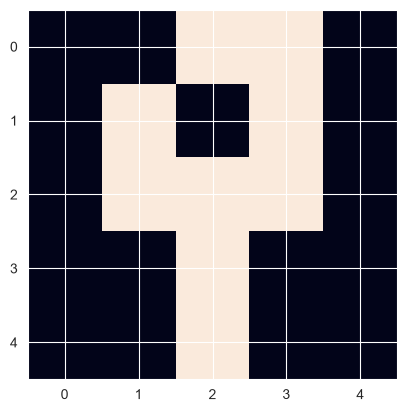

In [70]:
plt.imshow(image)

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression

In [73]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Ethnotech\Downloads\employee_supervised_learning_cleaned2.csv")

In [74]:
df.head(500)

,age,education_level,department,experience_years,performance_score,attendance_pct,training_hours,projects_completed,overtime_hours,leadership_score,job_satisfaction,current_salary,promoted,next_year_salary
0,22.0,Bachelor,HR,0.0,6.7,92.2,64.0,2.0,4.0,5.3,8.1,428000.0,0.0,583000.0
1,36.0,Master,Sales,14.0,7.0,82.7,73.0,10.0,24.0,5.4,10.0,1361000.0,0.0,1669000.0
2,55.0,Diploma,IT,30.0,5.9,86.9,60.0,19.0,15.0,5.4,6.3,1800000.0,0.0,2313000.0
3,54.0,Bachelor,HR,30.0,8.0,90.9,41.0,14.0,4.0,7.0,7.9,1800000.0,0.0,2392000.0
4,42.0,Master,HR,20.0,5.4,89.7,28.0,10.0,14.0,6.8,5.8,1695000.0,0.0,2074000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,37.0,Bachelor,Finance,8.0,8.8,93.8,49.0,7.0,26.0,7.4,9.4,1082000.0,0.0,1329000.0
496,35.0,Master,Sales,7.0,3.9,93.0,28.0,7.0,0.0,3.8,5.3,865000.0,0.0,1043000.0
497,53.0,Bachelor,Finance,25.0,7.2,91.8,78.0,18.0,7.0,6.9,8.5,1800000.0,0.0,2226000.0
498,37.0,Master,Finance,12.0,8.3,88.0,69.0,12.0,17.0,7.2,7.3,1381000.0,0.0,1694000.0


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 500 non-null    float64
 1   education_level     500 non-null    str    
 2   department          500 non-null    str    
 3   experience_years    500 non-null    float64
 4   performance_score   500 non-null    float64
 5   attendance_pct      500 non-null    float64
 6   training_hours      500 non-null    float64
 7   projects_completed  500 non-null    float64
 8   overtime_hours      500 non-null    float64
 9   leadership_score    500 non-null    float64
 10  job_satisfaction    500 non-null    float64
 11  current_salary      500 non-null    float64
 12  promoted            500 non-null    float64
 13  next_year_salary    500 non-null    float64
dtypes: float64(12), str(2)
memory usage: 55.0 KB


In [76]:
df.drop_duplicates()

,age,education_level,department,experience_years,performance_score,attendance_pct,training_hours,projects_completed,overtime_hours,leadership_score,job_satisfaction,current_salary,promoted,next_year_salary
0,22.0,Bachelor,HR,0.0,6.7,92.2,64.0,2.0,4.0,5.3,8.1,428000.0,0.0,583000.0
1,36.0,Master,Sales,14.0,7.0,82.7,73.0,10.0,24.0,5.4,10.0,1361000.0,0.0,1669000.0
2,55.0,Diploma,IT,30.0,5.9,86.9,60.0,19.0,15.0,5.4,6.3,1800000.0,0.0,2313000.0
3,54.0,Bachelor,HR,30.0,8.0,90.9,41.0,14.0,4.0,7.0,7.9,1800000.0,0.0,2392000.0
4,42.0,Master,HR,20.0,5.4,89.7,28.0,10.0,14.0,6.8,5.8,1695000.0,0.0,2074000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,35.0,Master,Sales,7.0,3.9,93.0,28.0,7.0,0.0,3.8,5.3,865000.0,0.0,1043000.0
497,53.0,Bachelor,Finance,25.0,7.2,91.8,78.0,18.0,7.0,6.9,8.5,1800000.0,0.0,2226000.0
498,37.0,Master,Finance,12.0,8.3,88.0,69.0,12.0,17.0,7.2,7.3,1381000.0,0.0,1694000.0
499,54.0,Bachelor,HR,28.0,6.7,90.6,43.0,19.0,24.0,5.6,8.4,1800000.0,0.0,2297000.0


In [77]:
df.describe()

,age,experience_years,performance_score,attendance_pct,training_hours,projects_completed,overtime_hours,leadership_score,job_satisfaction,current_salary,promoted,next_year_salary
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,5.000000e+02
mean,38.920000,14.624000,7.296800,90.844600,45.848000,10.900000,10.396000,6.202400,7.487600,1.326438e+06,0.010000,1.677608e+06
std,10.059223,9.667137,1.315938,4.750546,17.176815,5.592186,6.828796,1.158758,1.212876,4.864168e+05,0.099598,6.040924e+05
min,21.000000,0.000000,3.300000,75.900000,5.000000,0.000000,0.000000,3.000000,3.400000,2.850000e+05,0.000000,4.320000e+05
25%,30.000000,6.000000,6.400000,87.800000,34.000000,6.000000,5.000000,5.475000,6.700000,8.962500e+05,0.000000,1.163750e+06
50%,39.000000,15.000000,7.300000,90.900000,46.000000,11.000000,10.000000,6.200000,7.500000,1.474000e+06,0.000000,1.833000e+06
75%,48.000000,23.000000,8.200000,94.200000,57.000000,16.000000,15.000000,7.000000,8.400000,1.800000e+06,0.000000,2.255000e+06
max,55.000000,30.000000,10.000000,100.000000,100.000000,20.000000,33.000000,10.000000,10.000000,1.800000e+06,1.000000,2.440000e+06


In [78]:
missing = df.isnull().sum()
print(missing)

age                   2
education_level       2
department            2
experience_years      2
performance_score     2
attendance_pct        2
training_hours        2
projects_completed    2
overtime_hours        2
leadership_score      2
job_satisfaction      2
current_salary        2
promoted              2
next_year_salary      2
dtype: int64


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, recall_score, f1_score,precision_score,confusion_matrix
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [81]:
dh = pd.read_csv("hospital.csv")
dh.head()

,Patient_Name,Age,Blood_Pressure,Blood_Sugar,BMI,Diabetes
0,Scarlett Martin,35,123,138,27.8,Yes
1,Ella Anderson,32,148,121,39.5,Yes
2,Madison Davis,69,135,89,21.9,No
3,Abigail Miller,79,150,145,30.6,Yes
4,Evelyn Thompson,61,135,117,24.0,No


In [82]:
x = dh[["Age","Blood_Pressure","Blood_Sugar","BMI"]]
y = dh["Diabetes"]

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(predictions)

['Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes'
 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No'
 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes']


In [84]:
# Use 'macro', 'micro', or 'weighted' depending on your needs
average_method = 'weighted'

accuracy = accuracy_score(y_test, predictions) * 100
precision = precision_score(y_test, predictions, average=average_method) * 100
recall = recall_score(y_test, predictions, average=average_method) * 100
f1 = f1_score(y_test, predictions, average=average_method) * 100

print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1 Score:  {f1:.2f}%")


Accuracy:  84.00%
Precision: 85.49%
Recall:    84.00%
F1 Score:  84.21%


In [85]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(predictions)

['No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes'
 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No'
 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes']


In [86]:
# Use 'macro', 'micro', or 'weighted' depending on your needs
average_method = 'weighted'

accuracy = accuracy_score(y_test, predictions) * 100
precision = precision_score(y_test, predictions, average=average_method) * 100
recall = recall_score(y_test, predictions, average=average_method) * 100
f1 = f1_score(y_test, predictions, average=average_method) * 100

print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1 Score:  {f1:.2f}%")


Accuracy:  90.00%
Precision: 90.17%
Recall:    90.00%
F1 Score:  90.05%


In [87]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(predictions)

['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes'
 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'No'
 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes']


In [88]:
# Use 'macro', 'micro', or 'weighted' depending on your needs
average_method = 'weighted'

accuracy = accuracy_score(y_test, predictions) * 100
precision = precision_score(y_test, predictions, average=average_method) * 100
recall = recall_score(y_test, predictions, average=average_method) * 100
f1 = f1_score(y_test, predictions, average=average_method) * 100

print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1 Score:  {f1:.2f}%")


Accuracy:  94.00%
Precision: 94.13%
Recall:    94.00%
F1 Score:  94.03%


In [89]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(predictions)

['No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No'
 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes'
 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No'
 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes']


In [90]:
# Use 'macro', 'micro', or 'weighted' depending on your needs
average_method = 'weighted'

accuracy = accuracy_score(y_test, predictions) * 100
precision = precision_score(y_test, predictions, average=average_method) * 100
recall = recall_score(y_test, predictions, average=average_method) * 100
f1 = f1_score(y_test, predictions, average=average_method) * 100

print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1 Score:  {f1:.2f}%")


Accuracy:  90.00%
Precision: 90.88%
Recall:    90.00%
F1 Score:  90.11%


In [91]:
"""
1. Macro Average (The Unfairly Fair Way)Think of this like a school where every class gets one vote, no matter
 how many students are in it.
How it works: It calculates the score for Category A, Category B, and Category C separately, then takes the simple average of those three numbers.
When to use it: When you care just as much about your model getting rare categories right as you do about the common ones.
2. Weighted Average (The Realistic Way)Think of this like a vote where a class with 100 students gets 10 times more power than a class with 10 students.
How it works: It calculates the score for each category, but gives more weight to the categories that appear most often in your test data.When to use it:
When your data is imbalanced (e.g., 90% of your data is Category A, and only 5% is Category B) and you want your final score to reflect that reality.
3. Micro Average (The Grand Total Way)Instead of looking at categories individually, this looks at the big picture.
How it works: It lumps all the correct guesses and incorrect guesses from all categories into one giant pool and calculates a single overall score.
Note: For multi-class classification, Micro Precision, Micro Recall, and Accuracy will all give you the exact same number.
"""

'\n1. Macro Average (The Unfairly Fair Way)Think of this like a school where every class gets one vote, no matter\n how many students are in it.\nHow it works: It calculates the score for Category A, Category B, and Category C separately, then takes the simple average of those three numbers.\nWhen to use it: When you care just as much about your model getting rare categories right as you do about the common ones.\n2. Weighted Average (The Realistic Way)Think of this like a vote where a class with 100 students gets 10 times more power than a class with 10 students.\nHow it works: It calculates the score for each category, but gives more weight to the categories that appear most often in your test data.When to use it:\nWhen your data is imbalanced (e.g., 90% of your data is Category A, and only 5% is Category B) and you want your final score to reflect that reality.\n3. Micro Average (The Grand Total Way)Instead of looking at categories individually, this looks at the big picture.\nHow i

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, recall_score, f1_score,precision_score,confusion_matrix
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [93]:
dh = pd.read_csv("hospital.csv")
dh.head()

,Patient_Name,Age,Blood_Pressure,Blood_Sugar,BMI,Diabetes
0,Scarlett Martin,35,123,138,27.8,Yes
1,Ella Anderson,32,148,121,39.5,Yes
2,Madison Davis,69,135,89,21.9,No
3,Abigail Miller,79,150,145,30.6,Yes
4,Evelyn Thompson,61,135,117,24.0,No


In [94]:
x = dh[["Age","Blood_Sugar","Diabetes","Blood_Pressure"]]
y = dh["BMI"]

In [95]:
# Use 'macro', 'micro', or 'weighted' depending on your needs
average_method = 'weighted'

accuracy = accuracy_score(y_test, predictions) * 100
precision = precision_score(y_test, predictions, average=average_method) * 100
recall = recall_score(y_test, predictions, average=average_method) * 100
f1 = f1_score(y_test, predictions, average=average_method) * 100

print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1 Score:  {f1:.2f}%")


Accuracy:  90.00%
Precision: 90.88%
Recall:    90.00%
F1 Score:  90.11%


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, recall_score, f1_score,precision_score,confusion_matrix
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [99]:
dh = pd.read_csv("hospital.csv")
dh.head()

,Patient_Name,Age,Blood_Pressure,Blood_Sugar,BMI,Diabetes
0,Scarlett Martin,35,123,138,27.8,Yes
1,Ella Anderson,32,148,121,39.5,Yes
2,Madison Davis,69,135,89,21.9,No
3,Abigail Miller,79,150,145,30.6,Yes
4,Evelyn Thompson,61,135,117,24.0,No


In [100]:
x = dh[["Age","Blood_Sugar","BMI","Blood_Pressure"]]
y = dh["Diabetes"]

In [101]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(predictions)

['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'No'
 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes']


In [102]:
# Use 'macro', 'micro', or 'weighted' depending on your needs
average_method = 'weighted'
accuracy = accuracy_score(y_test, predictions) * 100
precision = precision_score(y_test, predictions, average=average_method) * 100
recall = recall_score(y_test, predictions, average=average_method) * 100
f1 = f1_score(y_test, predictions, average=average_method) * 100

print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1 Score:  {f1:.2f}%")

Accuracy:  92.00%
Precision: 92.43%
Recall:    92.00%
F1 Score:  92.07%


In [103]:
df.head()

,age,education_level,department,experience_years,performance_score,attendance_pct,training_hours,projects_completed,overtime_hours,leadership_score,job_satisfaction,current_salary,promoted,next_year_salary
0,22.0,Bachelor,HR,0.0,6.7,92.2,64.0,2.0,4.0,5.3,8.1,428000.0,0.0,583000.0
1,36.0,Master,Sales,14.0,7.0,82.7,73.0,10.0,24.0,5.4,10.0,1361000.0,0.0,1669000.0
2,55.0,Diploma,IT,30.0,5.9,86.9,60.0,19.0,15.0,5.4,6.3,1800000.0,0.0,2313000.0
3,54.0,Bachelor,HR,30.0,8.0,90.9,41.0,14.0,4.0,7.0,7.9,1800000.0,0.0,2392000.0
4,42.0,Master,HR,20.0,5.4,89.7,28.0,10.0,14.0,6.8,5.8,1695000.0,0.0,2074000.0


In [104]:
df.tail()

,age,education_level,department,experience_years,performance_score,attendance_pct,training_hours,projects_completed,overtime_hours,leadership_score,job_satisfaction,current_salary,promoted,next_year_salary
497,53.0,Bachelor,Finance,25.0,7.2,91.8,78.0,18.0,7.0,6.9,8.5,1800000.0,0.0,2226000.0
498,37.0,Master,Finance,12.0,8.3,88.0,69.0,12.0,17.0,7.2,7.3,1381000.0,0.0,1694000.0
499,54.0,Bachelor,HR,28.0,6.7,90.6,43.0,19.0,24.0,5.6,8.4,1800000.0,0.0,2297000.0
500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
Image = np.array([
    [0,255,255,255,0],
    [0,255,0,255,0],
    [0,255,255,255,0],
    [0,0,255,0,0],
    [0,0,255,0,0]
])

print(Image)

[[  0 255 255 255   0]
 [  0 255   0 255   0]
 [  0 255 255 255   0]
 [  0   0 255   0   0]
 [  0   0 255   0   0]]


In [111]:
Image_binary = ( Image >= 75).astype(int)
print(Image_binary)

[[0 1 1 1 0]
 [0 1 0 1 0]
 [0 1 1 1 0]
 [0 0 1 0 0]
 [0 0 1 0 0]]


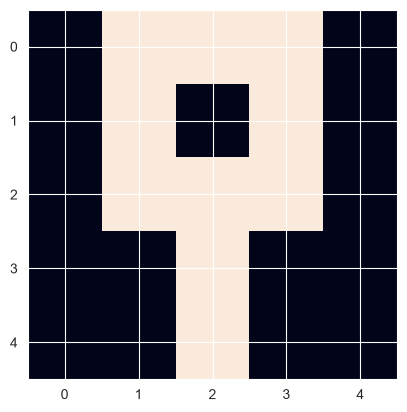

In [112]:
plt.imshow(Image)